# EuroSAT multispectral (13-band) exploration

This notebook summarizes the 13-band EuroSAT release on Hugging Face blanchon/EuroSAT_MSI. This dataset has 10 land-cover classes, 64×64×13 patches, and the same 60/20/20 splits as the RGB dataset. The goal of this notebook is to document value ranges and band behavior for normalization and reporting relative to [`01_data_exploration.ipynb`](01_data_exploration.ipynb).

## Setup

Figure files are written under `figures/` relative to the notebook working directory. [`train.py`](../train.py) applies ImageNet normalization only to three-channel RGB; thirteen-channel models should use band-wise statistics on the training data, as motivated by the histograms and moments below.

In [ ]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset

RNG = np.random.default_rng(42)
FIG_DIR = Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 200,
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "figure.figsize": (8, 4.5),
        "image.cmap": "viridis",
    }
)

# EuroSAT 13-band order (B01…B12 + B8A)same labels as in most EuroSAT MSI dumps.
BAND_NAMES = [
    "B01 (coastal)",
    "B02 (blue)",
    "B03 (green)",
    "B04 (red)",
    "B05 (re1)",
    "B06 (re2)",
    "B07 (re3)",
    "B08 (nir)",
    "B8A (nir narrow)",
    "B09 (vapour)",
    "B10 (cirrus)",
    "B11 (swir1)",
    "B12 (swir2)",
]
N_BANDS = len(BAND_NAMES)
I_B02, I_B03, I_B04, I_B08 = 1, 2, 3, 7  # blue, green, red, broad NIR

/Users/david/eurosat/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load

Same schema as RGB (`image`, `label`, `filename`), but numpy gives 64×64×13 HWC instead of 64x64x3.

In [ ]:
EuroSAT_MSI = load_dataset("blanchon/EuroSAT_MSI")
print(EuroSAT_MSI)
label_names = EuroSAT_MSI["train"].features["label"].names
num_classes = EuroSAT_MSI["train"].features["label"].num_classes
print("Classes:", label_names)
print("num_classes:", num_classes)

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 16200
    })
    test: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 5400
    })
    validation: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 5400
    })
})
Classes: ['Annual Crop', 'Forest', 'Herbaceous Vegetation', 'Highway', 'Industrial Buildings', 'Pasture', 'Permanent Crop', 'Residential Buildings', 'River', 'SeaLake']
num_classes: 10


### Values

Stored as integer reflectance (scaled DN), not 0–1 floats.

In [ ]:
def msi_to_array(ex_or_image):
    img = ex_or_image["image"] if isinstance(ex_or_image, dict) else ex_or_image
    arr = np.asarray(img, dtype=np.float64)
    if arr.ndim != 3 or arr.shape[-1] != N_BANDS:
        raise ValueError(f"Expected (H, W, {N_BANDS}), got {arr.shape}")
    return arr


for i in range(3):
    ex = EuroSAT_MSI["train"][i]
    a = msi_to_array(ex)
    print(
        i,
        ex["filename"],
        a.shape,
        a.dtype,
        float(a.min()),
        float(a.max()),
        "label:", label_names[ex["label"]],
    )

0 AnnualCrop_1.tif (64, 64, 13) float64 9.0 3490.0 label: Annual Crop
1 AnnualCrop_10.tif (64, 64, 13) float64 12.0 5754.0 label: Annual Crop
2 AnnualCrop_100.tif (64, 64, 13) float64 13.0 5168.0 label: Annual Crop


## Class counts (train)

Same ballpark as RGB — run the next cell and the bars sit in a tight band; I’m not reaching for class weights unless metrics look off.

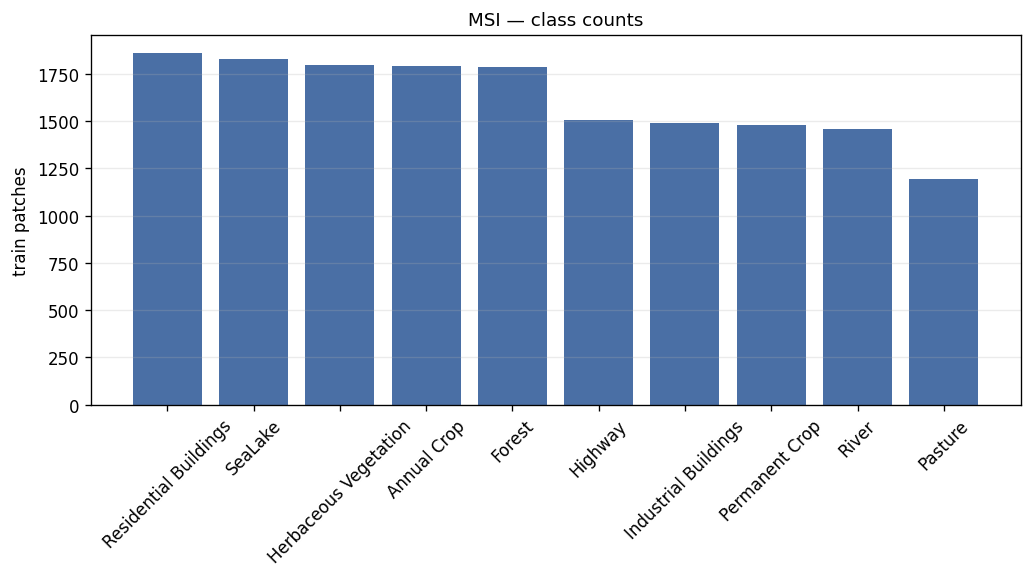

In [ ]:
labels = EuroSAT_MSI["train"]["label"]
counts = Counter(labels)
order = sorted(counts, key=lambda k: (-counts[k], k))
names = [label_names[i] for i in order]
vals = [counts[i] for i in order]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(names, vals, zorder=2)
ax.set_ylabel("train patches")
ax.set_title("MSI — class counts")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.5)
fig.savefig(FIG_DIR / "msi_class_distribution_train.png", bbox_inches="tight")
plt.show()

## RGB composites for display

Natural color stacks B04/B03/B02 as R/G/B. False color uses B08 on red so green stuff pops. I percentile-stretch each chip (2–98%) before `imshow` so single tiles aren’t blown out.

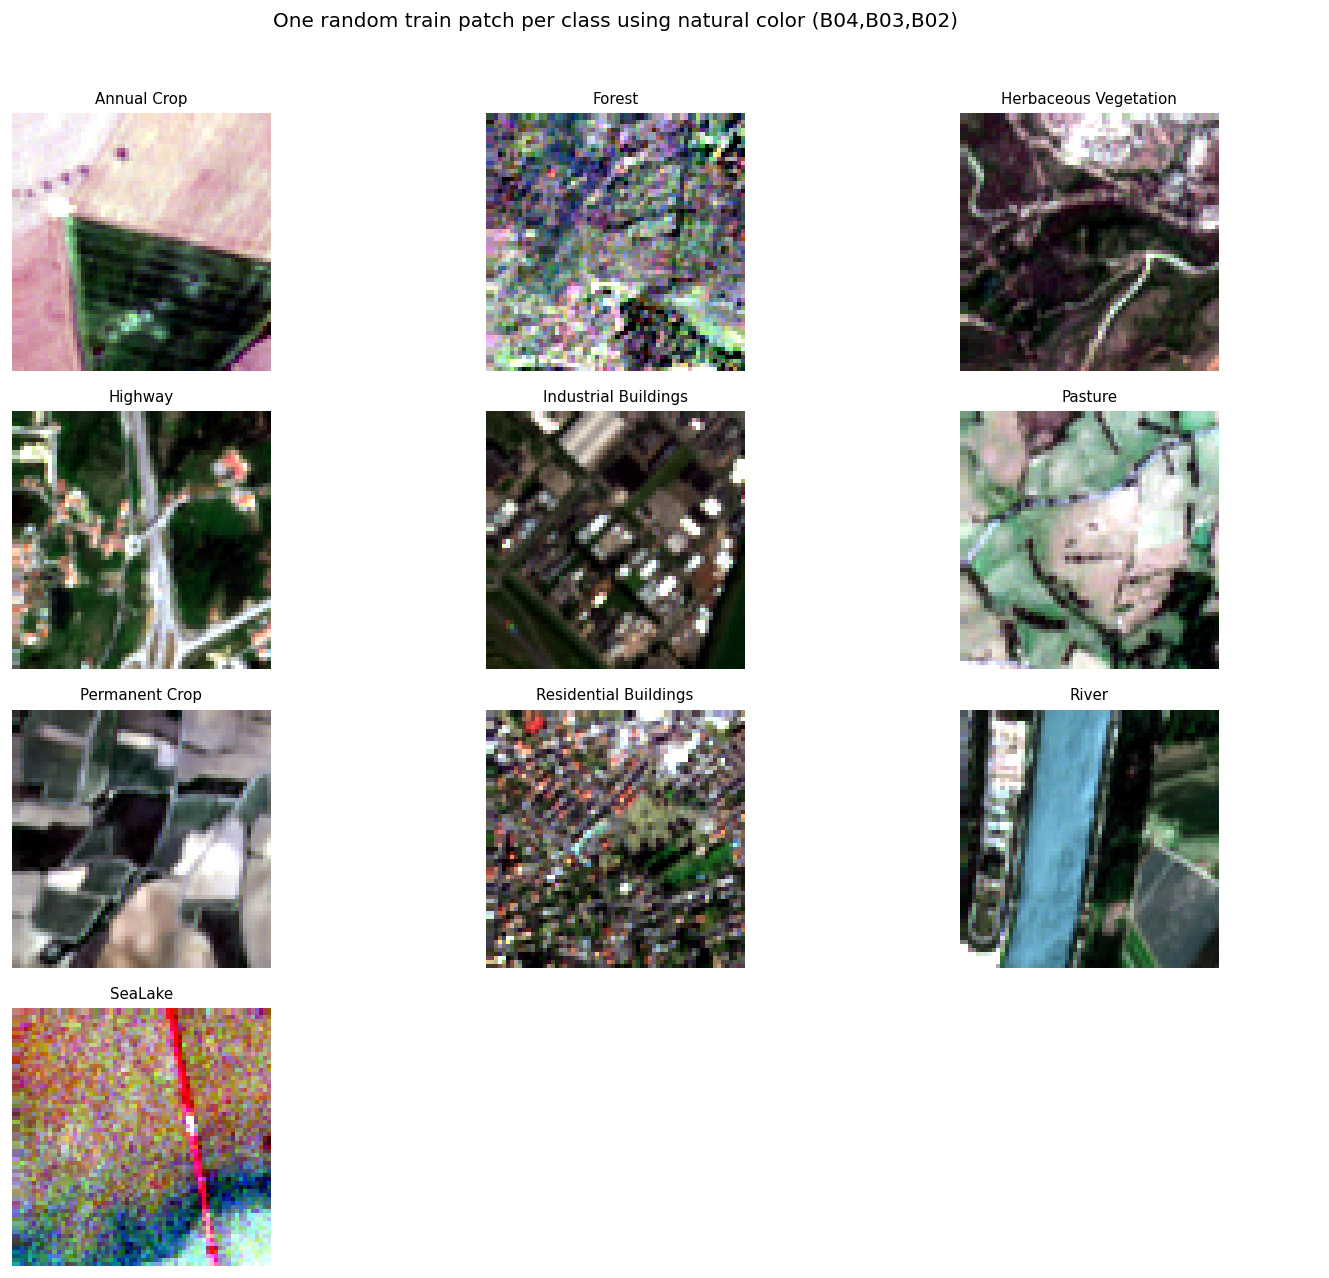

In [15]:
def percentile_stretch_hwc(rgb, p_low=2.0, p_high=98.0):
    out = np.empty_like(rgb, dtype=np.float64)
    for c in range(rgb.shape[-1]):
        band = rgb[..., c]
        lo, hi = np.percentile(band, (p_low, p_high))
        out[..., c] = np.clip((band - lo) / (hi - lo + 1e-9), 0.0, 1.0)
    return out


def msi_natural_color(arr_hwc):
    rgb = np.stack(
        [arr_hwc[..., I_B04], arr_hwc[..., I_B03], arr_hwc[..., I_B02]], axis=-1
    )
    return percentile_stretch_hwc(rgb)


def msi_false_color_nir(arr_hwc):
    rgb = np.stack(
        [arr_hwc[..., I_B08], arr_hwc[..., I_B04], arr_hwc[..., I_B03]], axis=-1
    )
    return percentile_stretch_hwc(rgb)


def pick_examples_per_class(ds_split, n_per_class=2, seed=42):
    rng = np.random.default_rng(seed)
    by_label = {c: [] for c in range(num_classes)}
    for idx, lab in enumerate(ds_split["label"]):
        by_label[lab].append(idx)
    picks = []
    for c in range(num_classes):
        idxs = by_label[c]
        take = rng.choice(idxs, size=min(n_per_class, len(idxs)), replace=False)
        for j in take:
            picks.append(ds_split[int(j)])
    return picks


examples = pick_examples_per_class(EuroSAT_MSI["train"], n_per_class=1, seed=42)
n = len(examples)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.6 * nrows))
axes = np.atleast_2d(axes)
for k, ex in enumerate(examples):
    r, col = divmod(k, ncols)
    ax = axes[r, col]
    arr = msi_to_array(ex)
    ax.imshow(msi_natural_color(arr))
    ax.set_title(label_names[ex["label"]], fontsize=9)
    ax.axis("off")
for k in range(n, nrows * ncols):
    r, col = divmod(k, ncols)
    axes[r, col].axis("off")
fig.suptitle("MSI natural color — one random train patch per class", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "msi_sample_grid_natural_color.png", bbox_inches="tight")
plt.show()

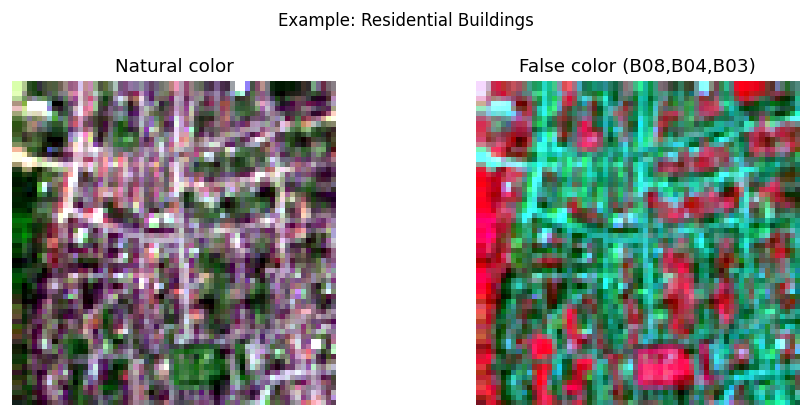

In [12]:
ex0 = EuroSAT_MSI["train"][RNG.integers(0, len(EuroSAT_MSI["train"]))]
arr0 = msi_to_array(ex0)
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
axes[0].imshow(msi_natural_color(arr0))
axes[0].set_title("Natural color")
axes[1].imshow(msi_false_color_nir(arr0))
axes[1].set_title("False color (B08,B04,B03)")
for ax in axes:
    ax.axis("off")
fig.suptitle(
    f"Example: {label_names[ex0['label']]}",
    fontsize=10,
)
fig.tight_layout()
fig.savefig(FIG_DIR / "msi_natural_vs_false_color.png", bbox_inches="tight")
plt.show()

## Per-band mean/std (stratified sample)

3k train patches (300/class) — enough for sane means without melting RAM. Bump `SUBSET_PER_CLASS` if you want tighter estimates.

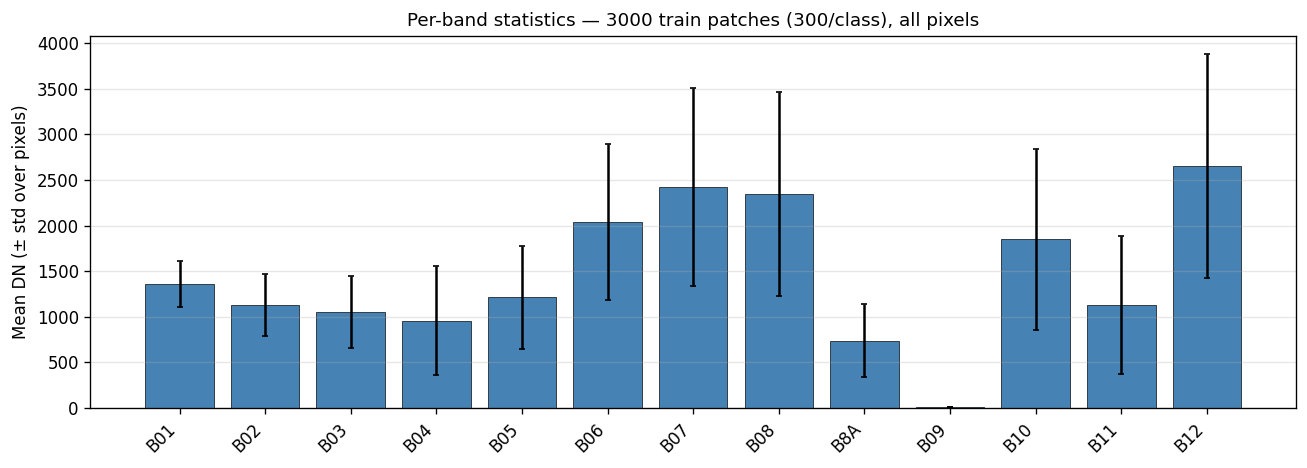

In [7]:
SUBSET_PER_CLASS = 300


def stratified_indices(ds_split, per_class, seed):
    rng = np.random.default_rng(seed)
    by_label = {c: [] for c in range(num_classes)}
    for idx, lab in enumerate(ds_split["label"]):
        by_label[lab].append(idx)
    out = []
    for c in range(num_classes):
        idxs = by_label[c]
        take = rng.choice(idxs, size=min(per_class, len(idxs)), replace=False)
        out.extend(int(t) for t in take)
    return np.array(out, dtype=np.int64)


idx_train = stratified_indices(EuroSAT_MSI["train"], SUBSET_PER_CLASS, seed=42)
stack = np.stack([msi_to_array(EuroSAT_MSI["train"][int(i)]) for i in idx_train], axis=0)
# stack: (N, H, W, C)
flat = stack.reshape(-1, N_BANDS)
band_mean = flat.mean(axis=0)
band_std = flat.std(axis=0)

x = np.arange(N_BANDS)
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x, band_mean, yerr=band_std, capsize=2, color="#4a6fa5", ecolor="#333", elinewidth=0.6)
ax.set_xticks(x)
ax.set_xticklabels([b.split()[0] for b in BAND_NAMES], rotation=45, ha="right")
ax.set_ylabel("mean DN ± std (pixels pooled)")
ax.set_title(f"{len(idx_train)} train patches × all pixels — mean per band")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "msi_per_band_mean_std.png", bbox_inches="tight")
plt.show()

### Histograms (same subset)

Bands don’t share one nice Gaussian — NIR/SWIR sit on different scales than visible. That’s the main reason I’d compute mean/std per channel on train instead of copy-pasting ImageNet RGB.

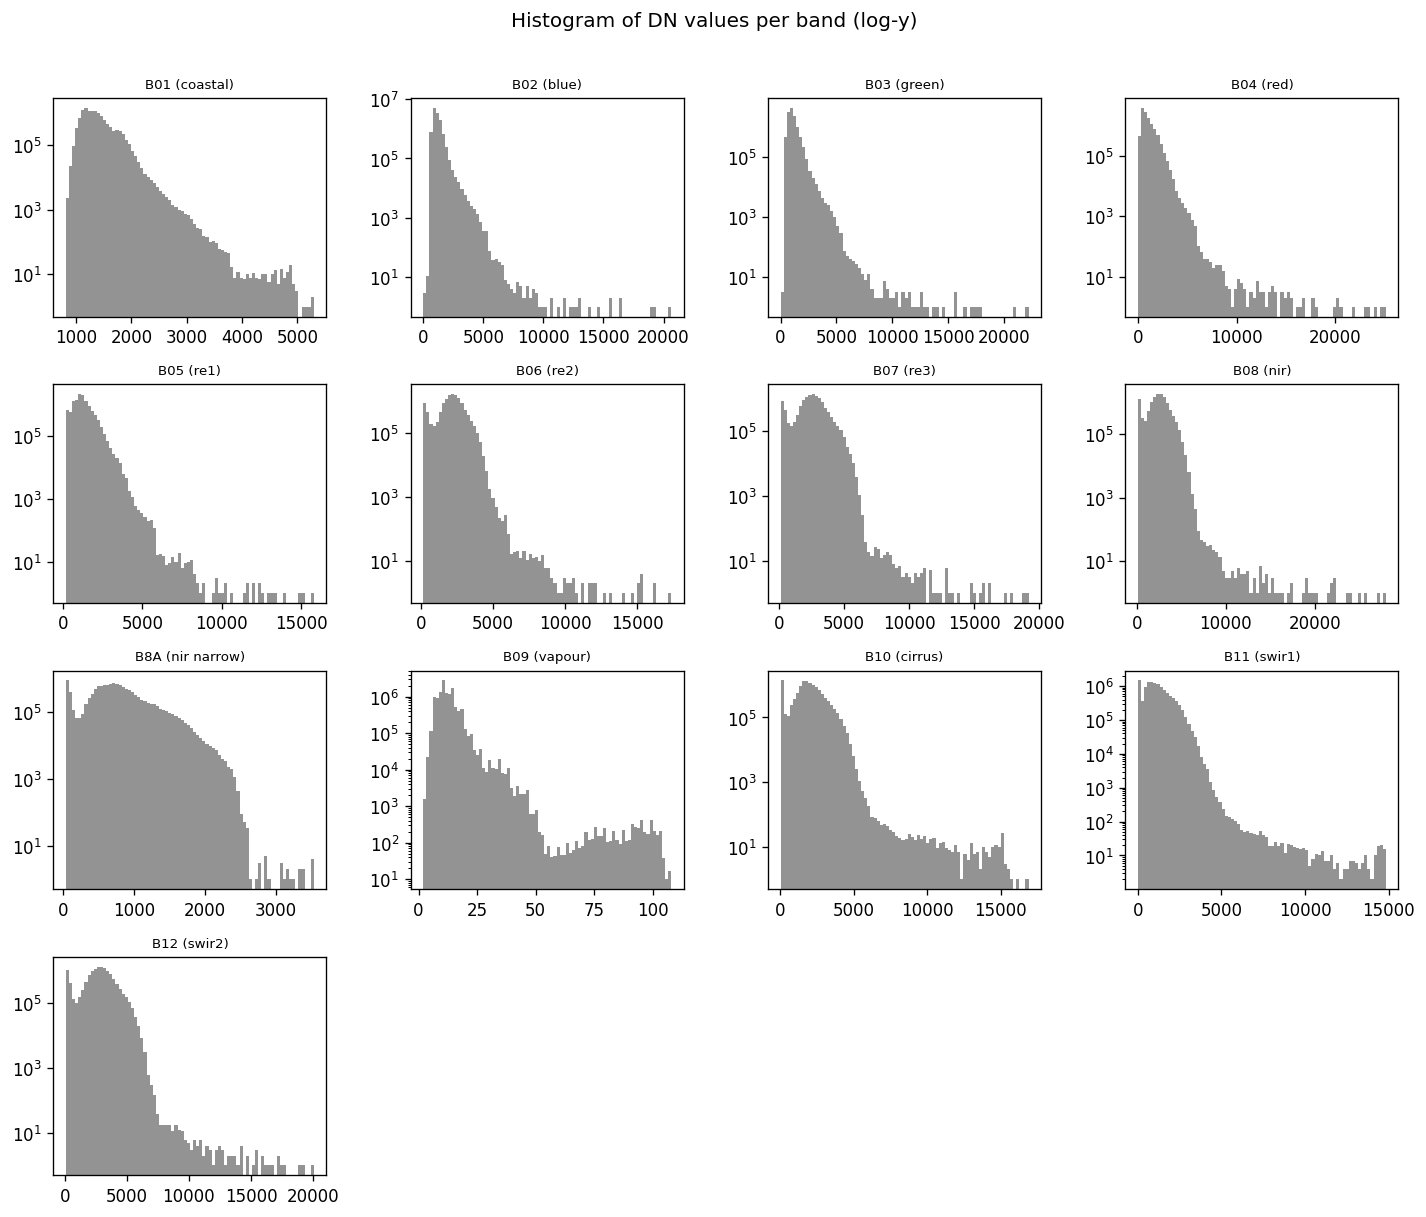

In [8]:
fig, axes = plt.subplots(4, 4, figsize=(12, 10))
axes = axes.ravel()
for b in range(N_BANDS):
    ax = axes[b]
    ax.hist(flat[:, b], bins=80, color="gray", alpha=0.85)
    ax.set_title(BAND_NAMES[b], fontsize=8)
    ax.set_yscale("log")
axes[-1].axis("off")
axes[-2].axis("off")
axes[-3].axis("off")
fig.suptitle("DN per band (log y-axis)", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "msi_per_band_histograms.png", bbox_inches="tight")
plt.show()

## Class-mean spectra

Average DN per band, per class, over the same stratified pixels. Vegetated classes usually peel away in NIR/red-edge; worth eyeballing before you decide whether MSI is buying you much over RGB.

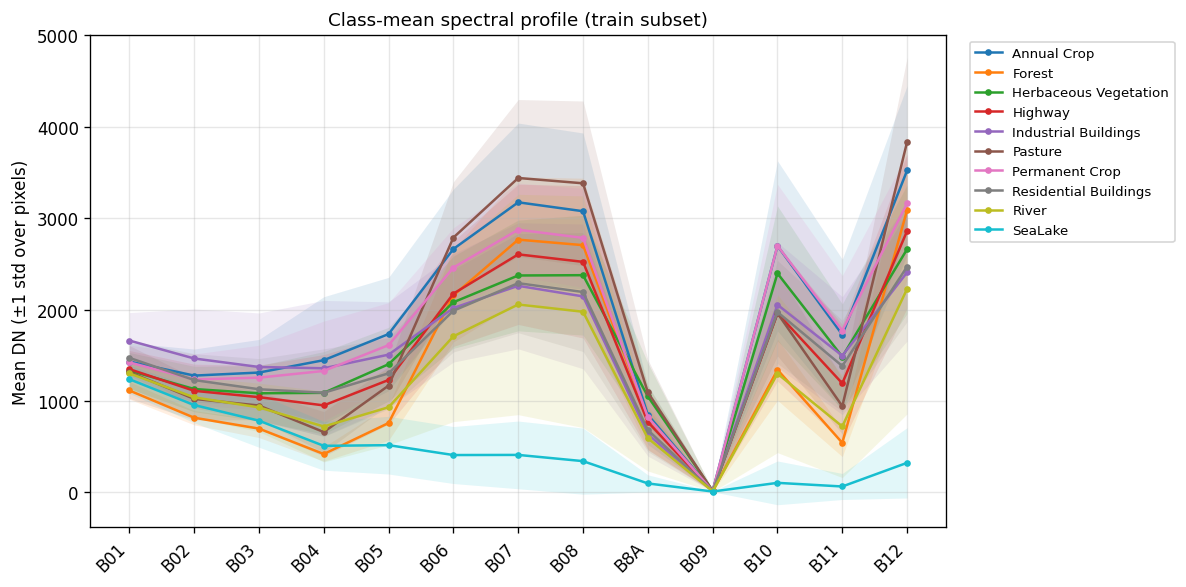

In [16]:
labels_sub = np.array([EuroSAT_MSI["train"][int(i)]["label"] for i in idx_train])
h, w = stack.shape[1], stack.shape[2]
pix_per_patch = h * w
labels_pixel = np.repeat(labels_sub, pix_per_patch)

class_mean = np.zeros((num_classes, N_BANDS))
for c in range(num_classes):
    sel = flat[labels_pixel == c]
    class_mean[c] = sel.mean(axis=0)

x = np.arange(N_BANDS)
fig, ax = plt.subplots(figsize=(10, 5))
for c in range(num_classes):
    ax.plot(x, class_mean[c], "-o", ms=3, lw=1.2, label=label_names[c])
ax.set_xticks(x)
ax.set_xticklabels([b.split()[0] for b in BAND_NAMES], rotation=45, ha="right")
ax.set_ylabel("mean DN (train subset, pooled pixels)")
ax.set_title("mean spectrum by class")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "msi_class_mean_spectrum.png", bbox_inches="tight")
plt.show()

## Band correlation

Neighboring bands correlate (expected). I mostly use this heatmap as a sanity check — if you regularize or drop bands later, you’ll see why some blocks are redundant.

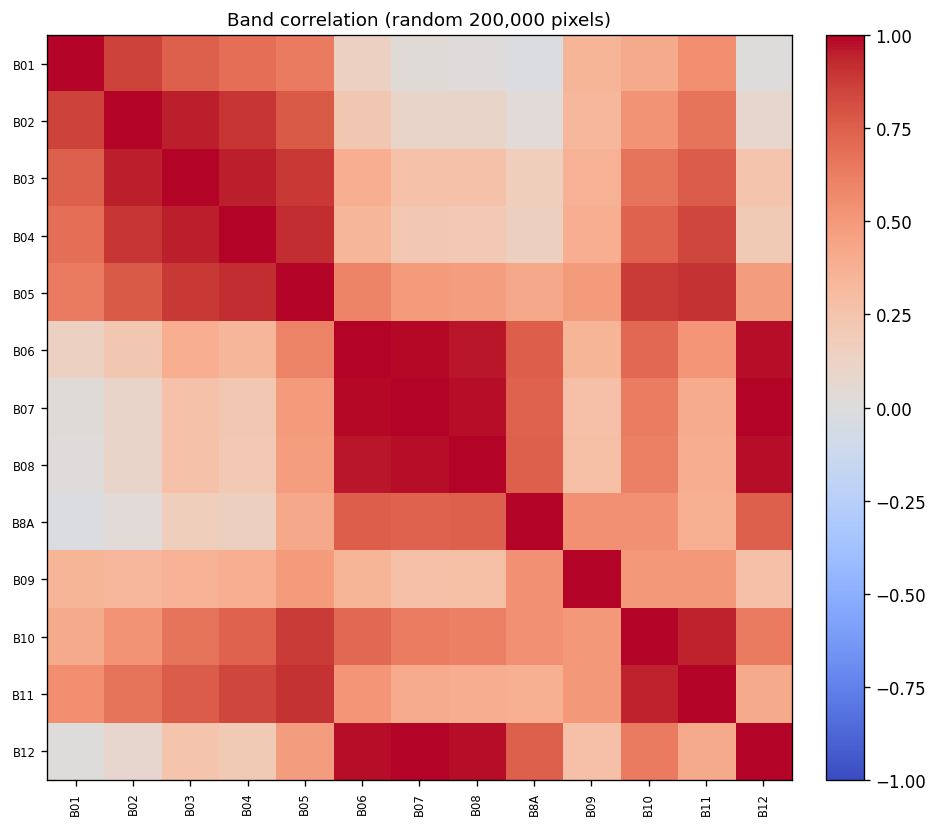

In [10]:
n_pix_sample = min(200_000, flat.shape[0])
rows = RNG.choice(flat.shape[0], size=n_pix_sample, replace=False)
sample = flat[rows]
corr = np.corrcoef(sample.T)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(N_BANDS))
ax.set_yticks(range(N_BANDS))
short = [b.split()[0] for b in BAND_NAMES]
ax.set_xticklabels(short, rotation=90, fontsize=7)
ax.set_yticklabels(short, fontsize=7)
ax.set_title(f"correlation — {n_pix_sample:,} random pixels")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(FIG_DIR / "msi_band_correlation.png", bbox_inches="tight")
plt.show()

## RGB vs MSI (matched `filename`)

Same tile name in both HF datasets = same location. Left is uint8 RGB; right is MSI run through the natural-color stretch above.

Train patches with matching filename in RGB and MSI: 16,200


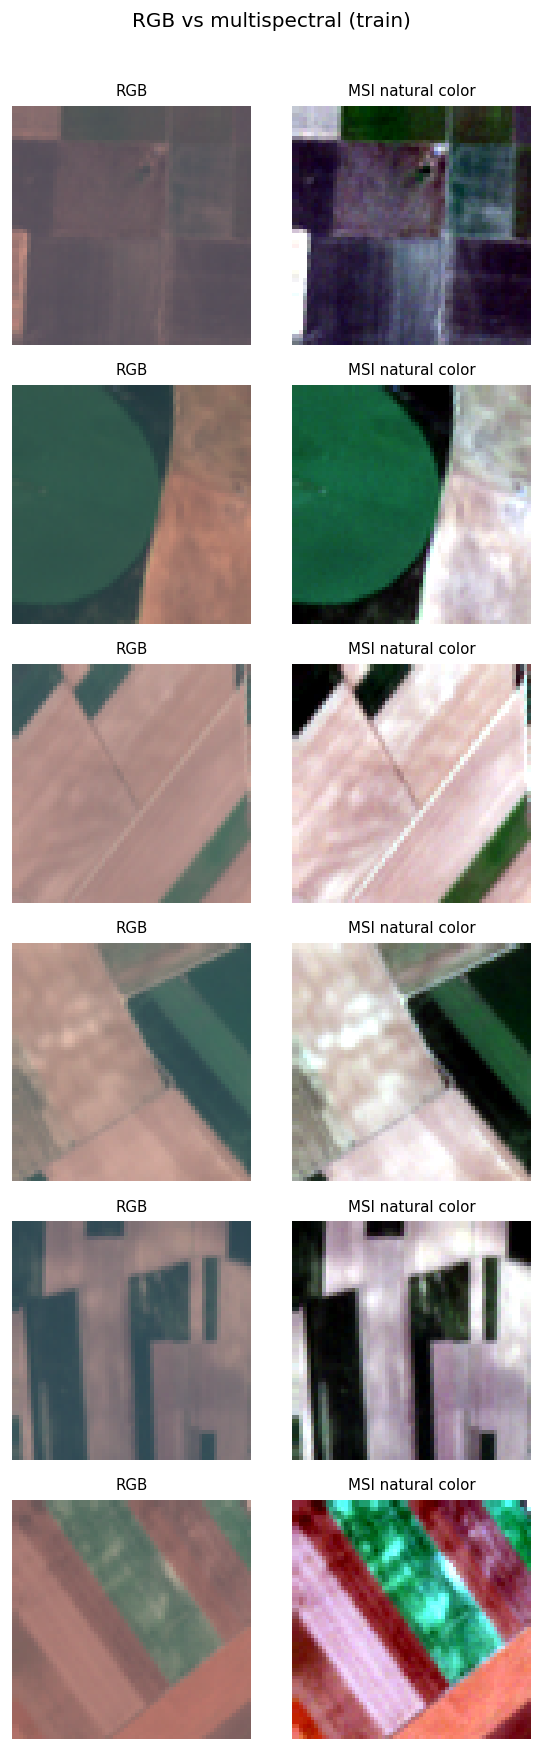

In [ ]:
EuroSAT_RGB = load_dataset("blanchon/EuroSAT_RGB")


def index_by_filename(split):
    return {split[i]["filename"]: i for i in range(len(split))}


rgb_train_by_fn = index_by_filename(EuroSAT_RGB["train"])
msi_train_by_fn = index_by_filename(EuroSAT_MSI["train"])
common = sorted(set(rgb_train_by_fn) & set(msi_train_by_fn))
print(f"Train patches with matching filename in RGB and MSI: {len(common):,}")

pick_fn = common[:6]
if len(pick_fn) < 6:
    pick_fn = common
fig, axes = plt.subplots(len(pick_fn), 2, figsize=(5, 2.4 * len(pick_fn)))
if len(pick_fn) == 1:
    axes = np.array([axes])
for row, fn in enumerate(pick_fn):
    ridx = rgb_train_by_fn[fn]
    midx = msi_train_by_fn[fn]
    rgb_ex = EuroSAT_RGB["train"][ridx]
    msi_ex = EuroSAT_MSI["train"][midx]
    rgb_arr = np.asarray(rgb_ex["image"], dtype=np.float64) / 255.0
    msi_arr = msi_to_array(msi_ex)

    axes[row, 0].imshow(np.clip(rgb_arr, 0, 1))
    axes[row, 0].set_title("RGB", fontsize=9)
    axes[row, 1].imshow(msi_natural_color(msi_arr))
    axes[row, 1].set_title("MSI natural color", fontsize=9)
    axes[row, 0].axis("off")
    axes[row, 1].axis("off")
fig.suptitle("RGB vs multispectral (train)", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "msi_vs_rgb_aligned.png", bbox_inches="tight")
plt.show()

## Training notes

`(13, H, W)` after CHW flip in PyTorch. Normalize with train-set per-band mean/std (or similar) — not ImageNet 3-vector. Figures land as `figures/msi_*.png` for writeups; band list is in the second code cell if you need citations.